In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# Load the CSV file
df = pd.read_csv("Cthulhu.csv")

# Preview the dataset
df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,selftext,link_flair_text,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.368729e+09,143,i.imgur.com,1egs0w,Cthulhu Cultist With Offering,redcell5,167,24,21,http://www.reddit.com/r/Cthulhu/comments/1egs0...,NaN,NaN,True,NaN,t5_2qmzi,False,NaN,NaN,False,t3_1egs0w,http://i.imgur.com/uhckBTC.jpg,NaN
1,1.359306e+09,127,therealsimivalleyhistoricalsociety.org,17dhkk,Cute-thulhu [GIF],kondrat1983,145,18,6,http://www.reddit.com/r/Cthulhu/comments/17dhk...,NaN,NaN,False,NaN,t5_2qmzi,False,NaN,NaN,False,t3_17dhkk,http://therealsimivalleyhistoricalsociety.org/...,NaN
2,1.355779e+09,132,i.imgur.com,150gvp,Snoopy as Cthulhu,VerGuy,146,14,5,http://www.reddit.com/r/Cthulhu/comments/150gv...,NaN,NaN,False,NaN,t5_2qmzi,False,NaN,NaN,False,t3_150gvp,http://i.imgur.com/xq0s4.jpg,NaN
3,1.344394e+09,128,i.qkme.me,xuyeu,The true beauty of his power,NaN,135,7,2,http://www.reddit.com/r/Cthulhu/comments/xuyeu...,NaN,NaN,False,NaN,t5_2qmzi,False,NaN,NaN,False,t3_xuyeu,http://i.qkme.me/3qe21p.jpg,NaN
4,1.368823e+09,124,imgur.com,1ejfsl,This is amazing.,Thepimpandthepriest,151,27,2,http://www.reddit.com/r/Cthulhu/comments/1ejfs...,NaN,NaN,False,NaN,t5_2qmzi,False,NaN,NaN,False,t3_1ejfsl,http://imgur.com/vOQciB1,NaN


In [3]:
# Dataset structure
df.info()

# Summary statistics
df.describe()

# Check for missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 594 entries, 0 to 593
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   created_utc             594 non-null    float64
 1   score                   594 non-null    int64  
 2   domain                  594 non-null    str    
 3   id                      594 non-null    str    
 4   title                   594 non-null    str    
 5   author                  552 non-null    str    
 6   ups                     594 non-null    int64  
 7   downs                   594 non-null    int64  
 8   num_comments            594 non-null    int64  
 9   permalink               594 non-null    str    
 10  selftext                60 non-null     str    
 11  link_flair_text         0 non-null      float64
 12  over_18                 594 non-null    bool   
 13  thumbnail               0 non-null      float64
 14  subreddit_id            594 non-null    str    
 15  

created_utc                 0
score                       0
domain                      0
id                          0
title                       0
author                     42
ups                         0
downs                       0
num_comments                0
permalink                   0
selftext                  534
link_flair_text           594
over_18                     0
thumbnail                 594
subreddit_id                0
edited                      0
link_flair_css_class      594
author_flair_css_class    594
is_self                     0
name                        0
url                         0
distinguished             593
dtype: int64

In [4]:
# Keep only numeric columns
X = df.select_dtypes(include=[np.number])

X.head()

,created_utc,score,ups,downs,num_comments,link_flair_text,thumbnail,link_flair_css_class,author_flair_css_class
0,1.368729e+09,143,167,24,21,NaN,NaN,NaN,NaN
1,1.359306e+09,127,145,18,6,NaN,NaN,NaN,NaN
2,1.355779e+09,132,146,14,5,NaN,NaN,NaN,NaN
3,1.344394e+09,128,135,7,2,NaN,NaN,NaN,NaN
4,1.368823e+09,124,151,27,2,NaN,NaN,NaN,NaN


In [8]:
import numpy as np
import pandas as pd

print(np.isnan(X).sum())
print(np.isinf(X).sum())

created_utc                 0
score                       0
ups                         0
downs                       0
num_comments                0
link_flair_text           594
thumbnail                 594
link_flair_css_class      594
author_flair_css_class    594
dtype: int64
created_utc               0
score                     0
ups                       0
downs                     0
num_comments              0
link_flair_text           0
thumbnail                 0
link_flair_css_class      0
author_flair_css_class    0
dtype: int64


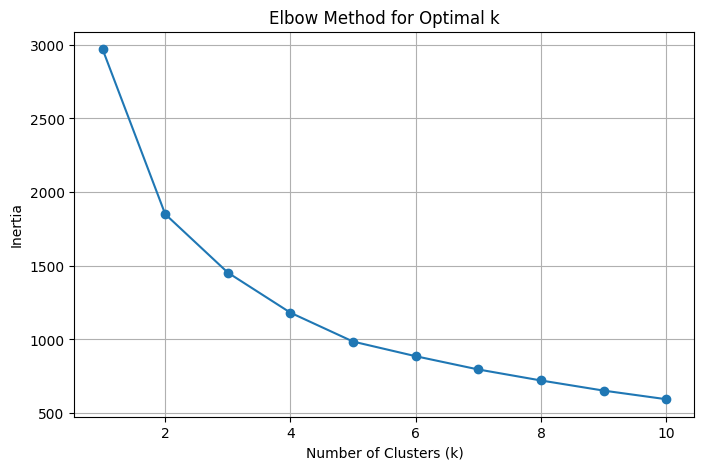

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# -----------------------------
# Assume your dataset is in X
# Example: X = pd.read_csv("your_dataset.csv")
# -----------------------------

# 1. Drop columns that contain only NaN values
X = X.dropna(axis=1, how='all')

# 2. Keep only numeric columns (K-Means requires numeric data)
X_numeric = X.select_dtypes(include=[np.number])

# 3. Handle missing values
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X_numeric)

# 4. Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 5. Apply the Elbow Method
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# 6. Plot the Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.show()

In [11]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,selftext,link_flair_text,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished,Cluster
0,1.368729e+09,143,i.imgur.com,1egs0w,Cthulhu Cultist With Offering,redcell5,167,24,21,http://www.reddit.com/r/Cthulhu/comments/1egs0...,NaN,NaN,True,NaN,t5_2qmzi,False,NaN,NaN,False,t3_1egs0w,http://i.imgur.com/uhckBTC.jpg,NaN,2
1,1.359306e+09,127,therealsimivalleyhistoricalsociety.org,17dhkk,Cute-thulhu [GIF],kondrat1983,145,18,6,http://www.reddit.com/r/Cthulhu/comments/17dhk...,NaN,NaN,False,NaN,t5_2qmzi,False,NaN,NaN,False,t3_17dhkk,http://therealsimivalleyhistoricalsociety.org/...,NaN,2
2,1.355779e+09,132,i.imgur.com,150gvp,Snoopy as Cthulhu,VerGuy,146,14,5,http://www.reddit.com/r/Cthulhu/comments/150gv...,NaN,NaN,False,NaN,t5_2qmzi,False,NaN,NaN,False,t3_150gvp,http://i.imgur.com/xq0s4.jpg,NaN,2
3,1.344394e+09,128,i.qkme.me,xuyeu,The true beauty of his power,NaN,135,7,2,http://www.reddit.com/r/Cthulhu/comments/xuyeu...,NaN,NaN,False,NaN,t5_2qmzi,False,NaN,NaN,False,t3_xuyeu,http://i.qkme.me/3qe21p.jpg,NaN,2
4,1.368823e+09,124,imgur.com,1ejfsl,This is amazing.,Thepimpandthepriest,151,27,2,http://www.reddit.com/r/Cthulhu/comments/1ejfs...,NaN,NaN,False,NaN,t5_2qmzi,False,NaN,NaN,False,t3_1ejfsl,http://imgur.com/vOQciB1,NaN,2


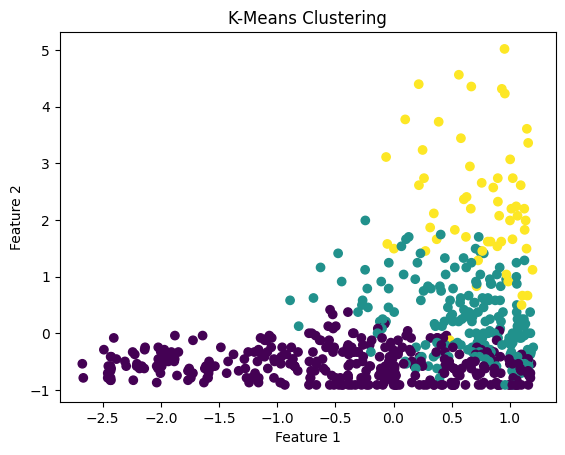

In [12]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering")

plt.show()

In [13]:
centers = kmeans.cluster_centers_

print("Cluster Centers:")
print(centers)

Cluster Centers:
[[-0.45655152 -0.53825997 -0.56095063 -0.44448005 -0.38633087]
 [ 0.61030623  0.28295918  0.29867441  0.24880405  0.4988926 ]
 [ 0.74268104  2.29822284  2.38276561  1.84845881  0.68562258]]
